# Lorenz Known-Structure: selected-epoch component 1 − corr² on test set

Reads each run's periodic `metrics_snapshot_e*.json` files under
`Lorenz_dyn_newtopo/results_knstruc/`.

Two loading modes are supported:
1. `SELECT_EPOCH = 2500` (or any integer): load exactly `metrics_snapshot_e{SELECT_EPOCH}.json`.
2. `SELECT_EPOCH = None` (default): compare all snapshots from epoch 1100 to 2500 and pick the best result for each metric family.

In auto-selection mode, **max** and **mean** use different criteria:
- **max metric / per-component curves:** compute `max(self_x_corr2, self_y_corr2, self_z_corr2, msg_corr2)` for every snapshot, then select the snapshot with the largest such corr².
- **mean metric:** read `best_component_mean_err` from every snapshot and select the minimum value (because it is already an error).

Note: Lorenz's `train_knstruc_Lorenz.py` saves the per-component goodness-of-fit
as **`self_x_corr2` / `self_y_corr2` / `self_z_corr2` / `msg_corr2`**
(correlation squared, ∈[0, 1], higher=better) — NOT the HR-style
`self_x_err` (= 1 − corr², lower=better). This notebook converts the four
component values to `1 − corr²` at load time so downstream plots are in the
same "error" units as `HR_dyn_new/analyze_knstruc_HR_last_epoch.ipynb`.
No model re-evaluation needed.


In [23]:
import os, re, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_hex

In [24]:
# ===== Settings =====
BASE_DIR = 'results_knstruc'
SCAN_NODE_SIZES = {5, 10, 15, 20}   # set to None for all
SELECT_EPOCH = None                 # int -> use metrics_snapshot_e{epoch}.json; None -> auto-pick best over epochs
AUTO_EPOCH_MIN = 1100
AUTO_EPOCH_MAX = 2500

PATTERN = re.compile(r'^Nodes(?P<nodes>\d+)_Ntrain(?P<ntrain>\d+)_hidden(?P<hidden>\d+)_seed(?P<seed>\d+)$')
print(f'BASE_DIR={BASE_DIR}')
print(f'SELECT_EPOCH={SELECT_EPOCH}')
print(f'AUTO_EPOCH_RANGE=[{AUTO_EPOCH_MIN}, {AUTO_EPOCH_MAX}]')


BASE_DIR=results_knstruc
SELECT_EPOCH=None
AUTO_EPOCH_RANGE=[1100, 2500]


In [25]:
# ===== Snapshot helpers =====
def list_snapshots(run_dir, epoch_min=AUTO_EPOCH_MIN, epoch_max=AUTO_EPOCH_MAX):
    """Return a sorted list of (epoch, path) for usable metrics snapshots."""
    out = []
    for path in glob.glob(os.path.join(run_dir, 'metrics_snapshot_e*.json')):
        m = re.search(r'e(\d+)', os.path.basename(path))
        if not m:
            continue
        ep = int(m.group(1))
        if epoch_min is not None and ep < epoch_min:
            continue
        if epoch_max is not None and ep > epoch_max:
            continue
        out.append((ep, path))
    return sorted(out)


def load_snapshot(path):
    with open(path) as f:
        return json.load(f)


def _corr2_to_err(c2):
    """1 - corr². Leaves NaN intact, clamps tiny negative values (numeric noise) to 0."""
    if c2 is None:
        return None
    v = 1.0 - float(c2)
    if np.isfinite(v) and v < 0 and v > -1e-9:
        return 0.0
    return v


def snapshot_component_payload(snap, epoch):
    sx = _corr2_to_err(snap.get('self_x_corr2'))
    sy = _corr2_to_err(snap.get('self_y_corr2'))
    sz = _corr2_to_err(snap.get('self_z_corr2'))
    mg = _corr2_to_err(snap.get('msg_corr2'))
    if any(v is None for v in (sx, sy, sz, mg)):
        return None
    corr_vals = [snap.get('self_x_corr2'), snap.get('self_y_corr2'), snap.get('self_z_corr2'), snap.get('msg_corr2')]
    corr_vals = [float(v) for v in corr_vals if v is not None]
    max_corr2 = float(np.nanmax(corr_vals)) if corr_vals else float(np.nanmax([1.0 - sx, 1.0 - sy, 1.0 - sz, 1.0 - mg]))
    return {
        'epoch': int(epoch),
        'self_x_err': float(sx),
        'self_y_err': float(sy),
        'self_z_err': float(sz),
        'msg_err': float(mg),
        'component_max_err': float(np.nanmax([sx, sy, sz, mg])),
        'component_mean_err_from_components': float(np.nanmean([sx, sy, sz, mg])),
        'max_corr2': max_corr2,
        'component_mean_err': snap.get('component_mean_err'),
        'best_component_mean_err': snap.get('best_component_mean_err'),
        'overall_r2': snap.get('overall_r2'),
        'node_r2_mean': snap.get('node_r2_mean'),
        'AUC': snap.get('AUC'),
        'AUPRC': snap.get('AUPRC'),
    }


def select_run_metrics(run_dir, select_epoch=SELECT_EPOCH):
    snaps = list_snapshots(run_dir)
    if not snaps:
        return None, 'no_snapshot'

    payloads = []
    for ep, path in snaps:
        if select_epoch is not None and ep != int(select_epoch):
            continue
        payload = snapshot_component_payload(load_snapshot(path), ep)
        if payload is not None:
            payloads.append(payload)

    if not payloads:
        if select_epoch is not None:
            return None, f'missing_epoch_{select_epoch}'
        return None, 'missing_component'

    if select_epoch is not None:
        chosen = payloads[0]
        return {
            'epoch_used_max': chosen['epoch'],
            'epoch_used_mean': chosen['epoch'],
            'selection_mode': f'fixed_e{chosen["epoch"]}',
            'self_x_err': chosen['self_x_err'],
            'self_y_err': chosen['self_y_err'],
            'self_z_err': chosen['self_z_err'],
            'msg_err': chosen['msg_err'],
            'component_max_err': chosen['component_max_err'],
            'component_mean_err': float(chosen.get('component_mean_err', chosen['component_mean_err_from_components'])),
            'component_mean_err_from_components': chosen['component_mean_err_from_components'],
            'component_mean_err_snap': chosen.get('component_mean_err'),
            'best_component_mean_err_selected': float(chosen.get('best_component_mean_err', chosen.get('component_mean_err', chosen['component_mean_err_from_components']))),
            'max_corr2_selected': chosen['max_corr2'],
            'overall_r2': chosen.get('overall_r2'),
            'node_r2_mean': chosen.get('node_r2_mean'),
            'AUC': chosen.get('AUC'),
            'AUPRC': chosen.get('AUPRC'),
        }, None

    best_max = max(payloads, key=lambda x: (x['max_corr2'], -x['epoch']))
    mean_candidates = [p for p in payloads if p.get('best_component_mean_err') is not None]
    if mean_candidates:
        best_mean = min(mean_candidates, key=lambda x: (float(x['best_component_mean_err']), x['epoch']))
        component_mean_err = float(best_mean['best_component_mean_err'])
        epoch_used_mean = int(best_mean['epoch'])
    else:
        best_mean = min(payloads, key=lambda x: (x['component_mean_err_from_components'], x['epoch']))
        component_mean_err = float(best_mean['component_mean_err_from_components'])
        epoch_used_mean = int(best_mean['epoch'])

    return {
        'epoch_used_max': int(best_max['epoch']),
        'epoch_used_mean': epoch_used_mean,
        'selection_mode': f'best_e{AUTO_EPOCH_MIN}_{AUTO_EPOCH_MAX}',
        'self_x_err': best_max['self_x_err'],
        'self_y_err': best_max['self_y_err'],
        'self_z_err': best_max['self_z_err'],
        'msg_err': best_max['msg_err'],
        'component_max_err': best_max['component_max_err'],
        'component_mean_err': component_mean_err,
        'component_mean_err_from_components': best_max['component_mean_err_from_components'],
        'component_mean_err_snap': best_max.get('component_mean_err'),
        'best_component_mean_err_selected': component_mean_err,
        'max_corr2_selected': best_max['max_corr2'],
        'overall_r2': best_max.get('overall_r2'),
        'node_r2_mean': best_max.get('node_r2_mean'),
        'AUC': best_max.get('AUC'),
        'AUPRC': best_max.get('AUPRC'),
    }, None


In [26]:
# (helper functions not needed — reading from JSON directly)

In [27]:
# (model loading not needed — reading from JSON directly)

In [28]:
# ===== Scan runs =====
# Lorenz train script saves per-component `corr^2` (higher=better). We load
# either a fixed epoch or the best snapshot(s) over epochs and convert the
# selected metrics to error units (`1 - corr^2`) for plotting.
rows = []
skipped = 0
skipped_reasons = {}
for entry in sorted(os.listdir(BASE_DIR)):
    full = os.path.join(BASE_DIR, entry)
    if not os.path.isdir(full):
        continue
    m = PATTERN.match(entry)
    if not m:
        continue
    num_nodes = int(m.group('nodes'))
    if SCAN_NODE_SIZES is not None and num_nodes not in SCAN_NODE_SIZES:
        continue
    num_train = int(m.group('ntrain'))
    hidden = int(m.group('hidden'))
    seed = int(m.group('seed'))

    selected, reason = select_run_metrics(full, select_epoch=SELECT_EPOCH)
    if selected is None:
        skipped += 1
        skipped_reasons[reason] = skipped_reasons.get(reason, 0) + 1
        continue

    rows.append({
        'run_name': entry,
        'num_nodes': num_nodes,
        'num_train_samples': num_train,
        'total_samples': num_nodes * num_train,
        'hidden': hidden,
        'seed': seed,
        'err_fx': selected['self_x_err'],
        'err_fy': selected['self_y_err'],
        'err_fz': selected['self_z_err'],
        'err_G': selected['msg_err'],
        'max_err': selected['component_max_err'],
        'mean_err': selected['component_mean_err'],
        'mean_err_from_components': selected['component_mean_err_from_components'],
        'component_mean_err_snap': selected['component_mean_err_snap'],
        'best_component_mean_err_selected': selected['best_component_mean_err_selected'],
        'epoch_used_max': selected['epoch_used_max'],
        'epoch_used_mean': selected['epoch_used_mean'],
        'selection_mode': selected['selection_mode'],
        'max_corr2_selected': selected['max_corr2_selected'],
    })

df = pd.DataFrame(rows)
print(f'loaded {len(df)} runs, skipped {skipped} {skipped_reasons}')
if len(df):
    print('num_nodes:', sorted(df.num_nodes.unique()))
    print('seeds:   ', sorted(df.seed.unique()))
    print('epoch_used_max range :', df.epoch_used_max.min(), '-', df.epoch_used_max.max())
    print('epoch_used_mean range:', df.epoch_used_mean.min(), '-', df.epoch_used_mean.max())
    if SELECT_EPOCH is not None:
        diff = (df['mean_err'] - df['component_mean_err_snap']).abs().max()
        print(f'max |mean_err - snap component_mean_err| = {diff:.3e}')
    else:
        print('auto mode: max/per-component and mean may come from different epochs per run')
df.head()


loaded 445 runs, skipped 0 {}
num_nodes: [5, 10, 15, 20]
seeds:    [1, 2, 3, 4, 5]
epoch_used_max range : 1100 - 2500
epoch_used_mean range: 1100 - 2500
auto mode: max/per-component and mean may come from different epochs per run


,run_name,num_nodes,num_train_samples,total_samples,hidden,seed,err_fx,err_fy,err_fz,err_G,max_err,mean_err,mean_err_from_components,component_mean_err_snap,best_component_mean_err_selected,epoch_used_max,epoch_used_mean,selection_mode,max_corr2_selected
0,Nodes10_Ntrain11_hidden50_seed1,10,11,110,50,1,0.001378,0.051583,0.023810,0.042964,0.051583,0.029541,0.029934,0.029934,0.029541,2400,2100,best_e1100_2500,0.998622
1,Nodes10_Ntrain11_hidden50_seed2,10,11,110,50,2,0.000927,0.040973,0.032884,0.043574,0.043574,0.029100,0.029590,0.029590,0.029100,2400,1800,best_e1100_2500,0.999073
2,Nodes10_Ntrain11_hidden50_seed3,10,11,110,50,3,0.000771,0.051453,0.030161,0.026083,0.051453,0.027034,0.027117,0.027117,0.027034,2400,2300,best_e1100_2500,0.999229
3,Nodes10_Ntrain11_hidden50_seed4,10,11,110,50,4,0.001131,0.050275,0.034086,0.020993,0.050275,0.026531,0.026621,0.026621,0.026531,2200,2300,best_e1100_2500,0.998869
4,Nodes10_Ntrain11_hidden50_seed5,10,11,110,50,5,0.001530,0.059114,0.023752,0.058501,0.059114,0.034714,0.035725,0.035725,0.034714,1900,1300,best_e1100_2500,0.998470


In [29]:
# ===== Aggregate over seeds =====
ERR_COLS = ['err_fx', 'err_fy', 'err_fz', 'err_G', 'max_err', 'mean_err']
agg_kw = {}
for c in ERR_COLS:
    agg_kw[f'mean_{c}'] = (c, 'mean')
    agg_kw[f'std_{c}']  = (c, 'std')
agg_kw['count'] = ('err_G', 'count')
agg_kw['total_samples'] = ('total_samples', 'first')

agg = (df.groupby(['num_nodes', 'num_train_samples'])
         .agg(**agg_kw).reset_index()
         .sort_values(['num_nodes', 'total_samples']))
node_counts = sorted(df.num_nodes.unique())
print('node sizes:', node_counts)
agg.head()


node sizes: [5, 10, 15, 20]


,num_nodes,num_train_samples,mean_err_fx,std_err_fx,mean_err_fy,std_err_fy,mean_err_fz,std_err_fz,mean_err_G,std_err_G,mean_max_err,std_max_err,mean_mean_err,std_mean_err,count,total_samples
0,5,2,0.565285,0.127789,0.879512,0.040560,0.805460,0.061111,0.648136,0.220961,0.882307,0.039139,0.696269,0.065046,5,10
1,5,5,0.058186,0.018781,0.949935,0.032159,0.312571,0.036126,0.536002,0.195973,0.949935,0.032159,0.428852,0.054397,5,25
2,5,8,0.023774,0.007537,0.496439,0.057397,0.121682,0.025963,0.589808,0.215979,0.638706,0.172414,0.290256,0.058362,5,40
3,5,11,0.006362,0.002669,0.072455,0.013929,0.034296,0.007599,0.465065,0.102068,0.465065,0.102068,0.128568,0.026757,5,55
4,5,14,0.007185,0.003041,0.099883,0.024123,0.045377,0.022646,0.356000,0.200021,0.356000,0.200021,0.109843,0.056774,5,70


In [38]:
# ===== Color map =====
plot_tag = f'e{SELECT_EPOCH}' if SELECT_EPOCH is not None else 'best over epochs'
# Previous olive palette kept here for reference:
# _cmap = LinearSegmentedColormap.from_list('hr_nodes', ['#C8C98A', '#AEB36D', '#8E9957', '#667A45', '#3F5636'])
_cmap = LinearSegmentedColormap.from_list('hr_nodes', ['#C2CBB8', '#9FAF97', '#7E9078', '#61735F', '#465748'])
node_color = {n: to_hex(_cmap(i / max(len(node_counts) - 1, 1))) for i, n in enumerate(node_counts)}


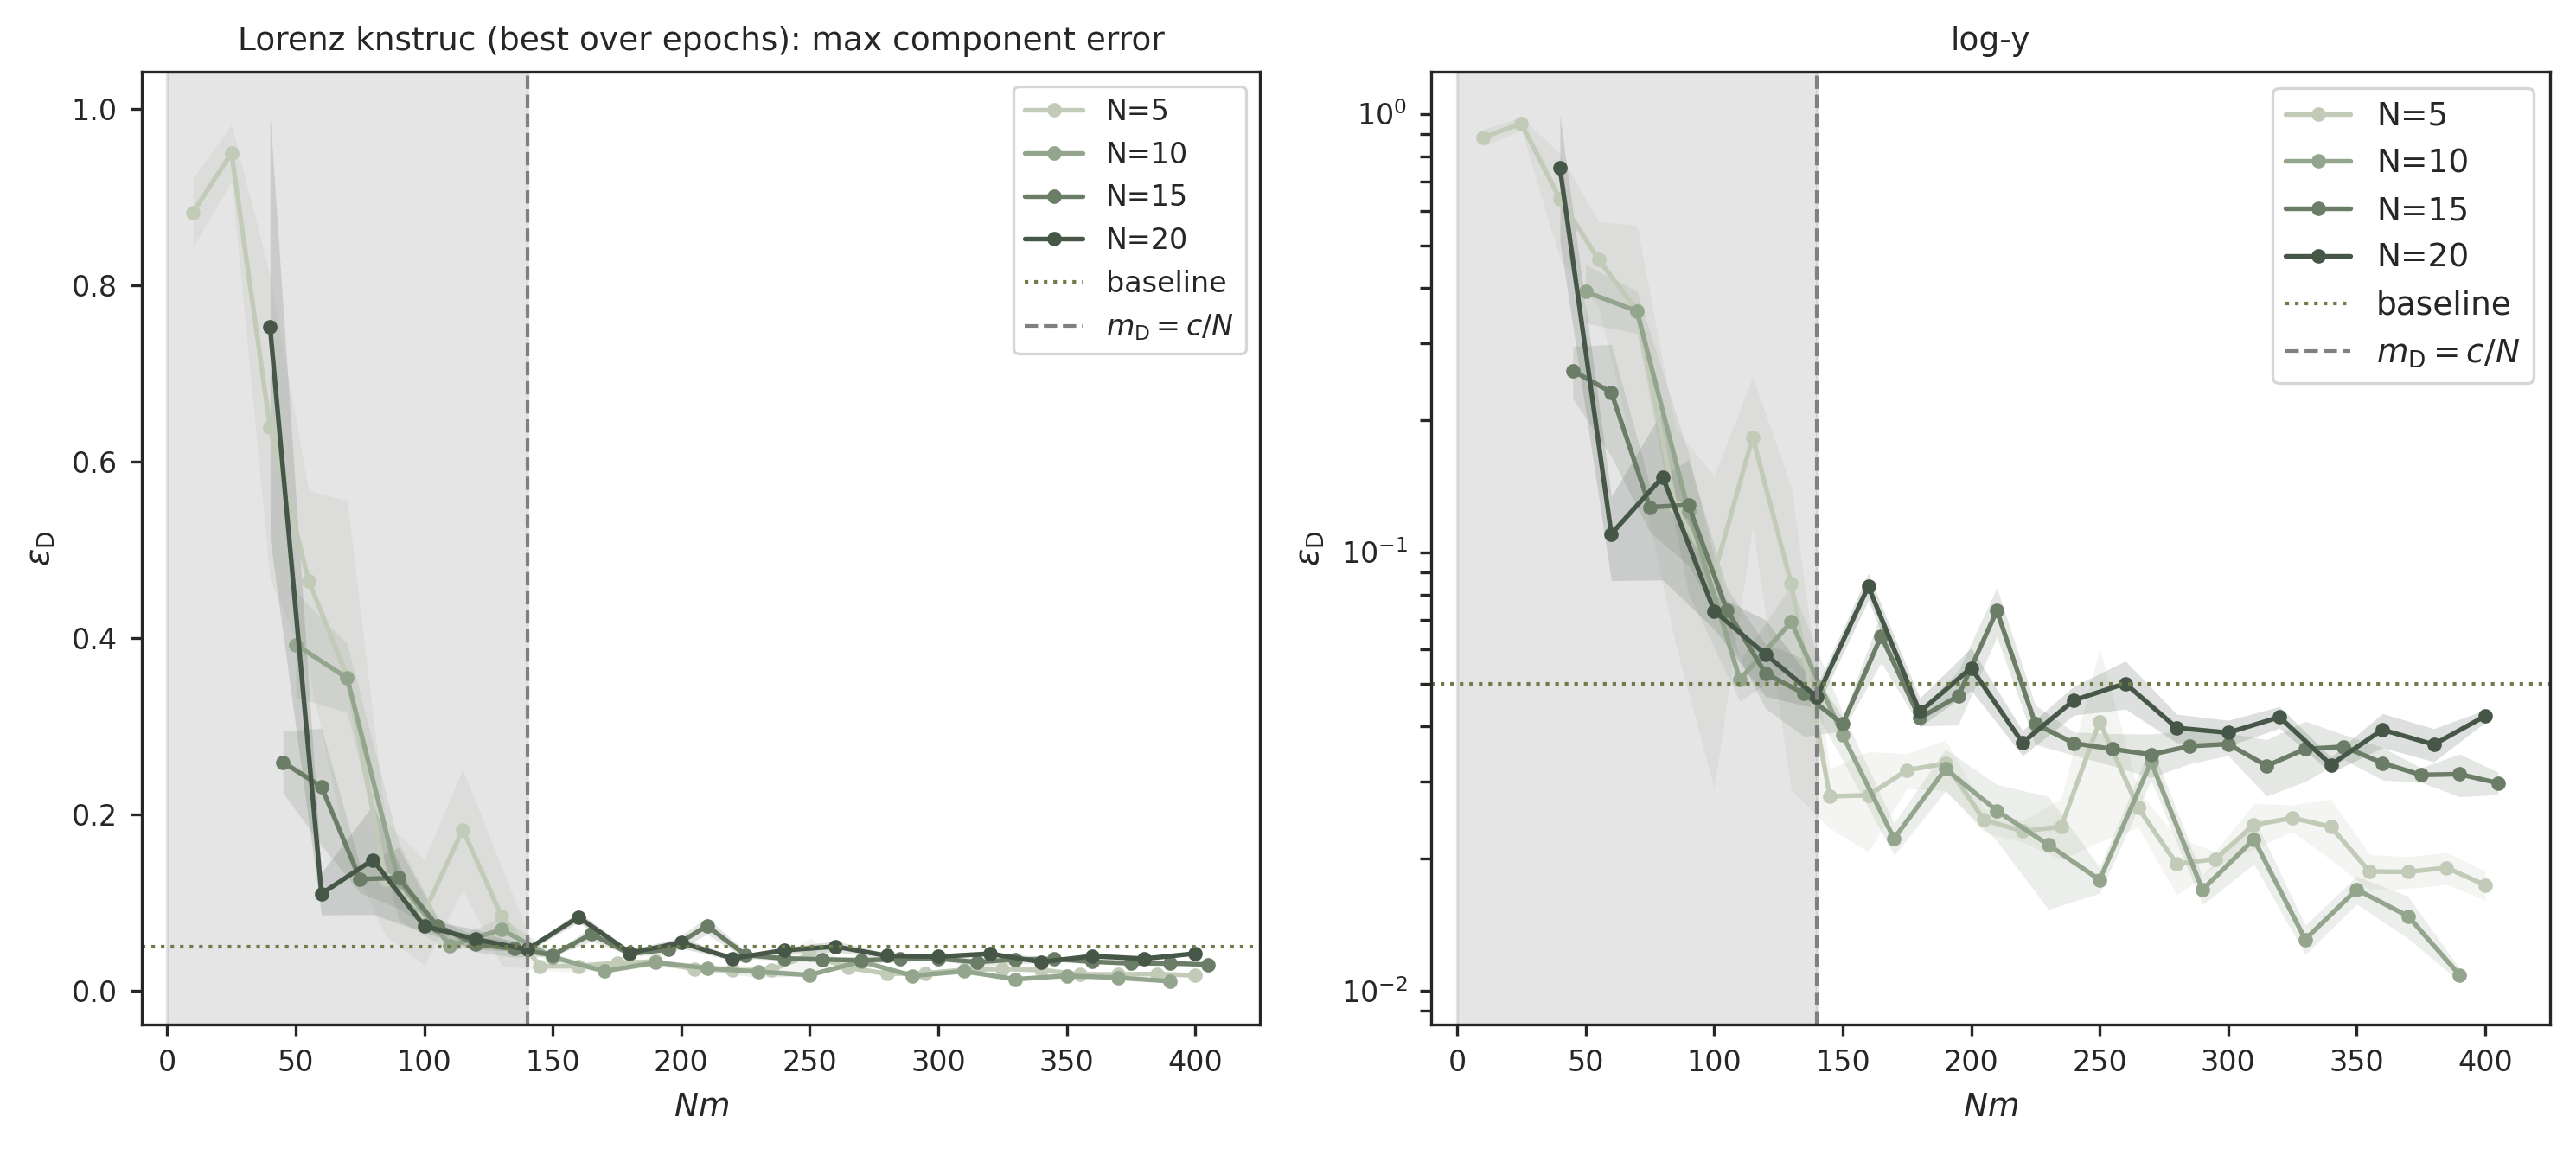

In [ ]:
# ===== Plot 1: max component error vs N * num_sample_per_node =====
import seaborn as sns
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.2,
    "ytick.major.size": 3.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "savefig.dpi": 300,
})

sns.set_theme(
    context="paper",
    style="white",
    rc={
        **mpl.rcParams,
        "xtick.bottom": True,
        "ytick.left": True,
        "xtick.direction": "out",
        "ytick.direction": "out",
    },
)
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(10, 4.5), dpi=300)
for ax, yscale in [(ax_lin, 'linear'), (ax_log, 'log')]:
    for n in node_counts:
        s = agg[agg.num_nodes == n].sort_values('total_samples')
        if s.empty:
            continue
        x = s['total_samples'].values
        y = s['mean_max_err'].values
        yerr = s['std_max_err'].values
        c = node_color[n]
        ax.plot(x, y, 'o-', color=c, ms=3, lw=1.3, label=f'N={n}')
        ax.fill_between(x, np.clip(y - yerr, 1e-6, None), y + yerr,
                        color=c, alpha=0.18, linewidth=0)
    ax.axhline(0.05, color='#6F7C4A', ls='dotted', lw=1, label='baseline')
    ax.axvline(140, color='gray', ls='--', lw=1, label='$m_\mathrm{D}=c/N$ ')  # for HR
    ax.axvspan(0, 140, color='gray', alpha=0.2)
    ax.set_xlim(left=-10)
    ax.set_xlabel('$Nm$')
    ax.set_ylabel('$\epsilon_\mathrm{D}$')
    ax.set_yscale(yscale)
    ax.legend()
    # ax.grid(alpha=0.3)
ax_lin.set_title(f'Lorenz knstruc ({plot_tag}): max component error')
ax_log.set_title('log-y')
ax_log.legend(fontsize=9, loc='best')
plt.tight_layout()
# plt.savefig(f'knstruc_Lorenz_max_err_{plot_tag}.pdf')
plt.show()


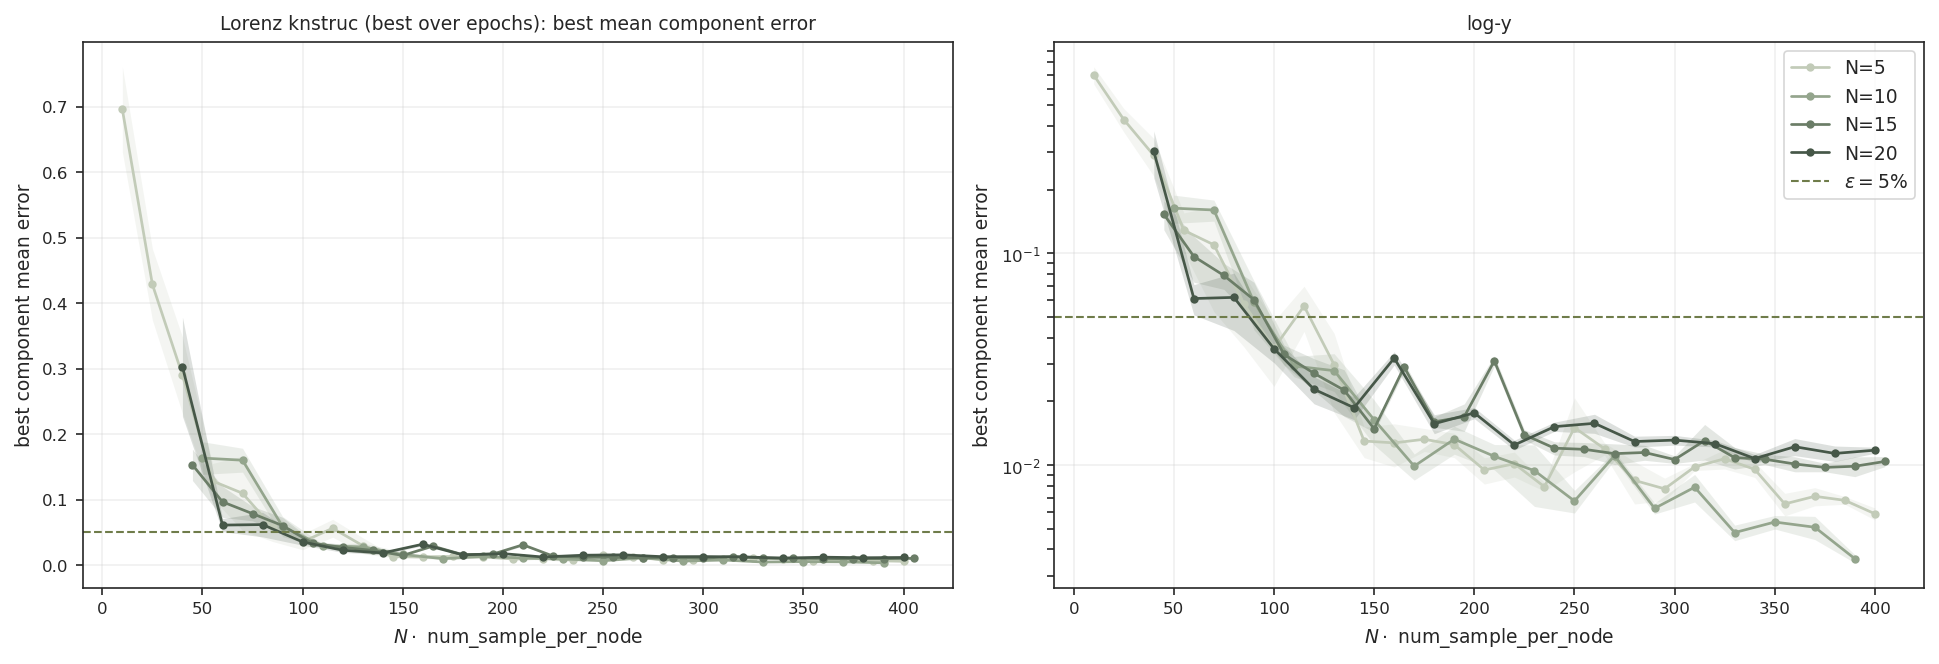

In [46]:
# ===== Plot: MEAN component error vs N * num_sample_per_node =====
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)

for ax, yscale in [(ax_lin, 'linear'), (ax_log, 'log')]:
    for n in node_counts:
        s = agg[agg.num_nodes == n].sort_values('total_samples')
        if s.empty:
            continue
        x = s['total_samples'].values
        y = s['mean_mean_err'].values
        yerr = s['std_mean_err'].values
        c = node_color[n]
        ax.plot(x, y, 'o-', color=c, ms=3, lw=1.3, label=f'N={n}')
        ax.fill_between(x, np.clip(y - yerr, 1e-6, None), y + yerr,
                        color=c, alpha=0.18, linewidth=0)
    ax.axhline(0.05, color='#6F7C4A', ls='--', lw=1, label='$\epsilon=5\%$')
    ax.set_xlabel('$N \cdot$ num_sample_per_node')
    ax.set_ylabel('best component mean error')
    ax.set_yscale(yscale)
    ax.grid(alpha=0.3)
ax_lin.set_title(f'Lorenz knstruc ({plot_tag}): best mean component error')
ax_log.set_title('log-y')
ax_log.legend(fontsize=9, loc='best')
plt.tight_layout(); plt.show()


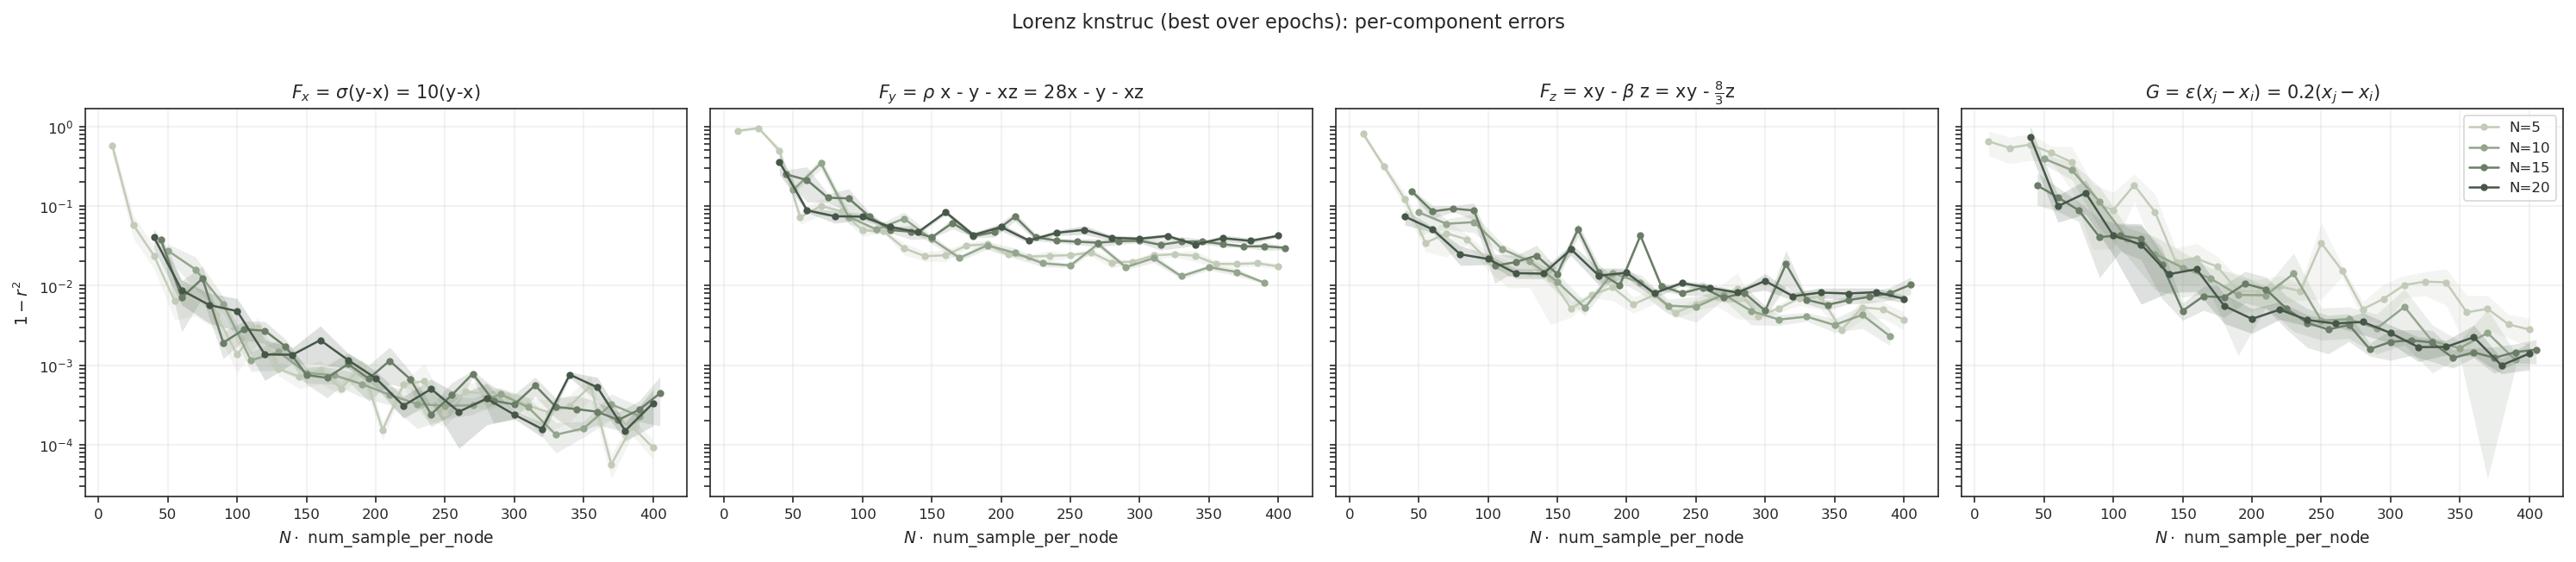

In [47]:
# ===== Plot 2: per-component errors =====
# Lorenz equations (see Lorenz_dyn/train_knstruc_Lorenz.py):
#   F_x = sigma (y - x)       = 10 (y - x)
#   F_y = rho x - y - x z     = 28 x - y - x z
#   F_z = x y - beta z        = x y - (8/3) z
#   G   = epsilon (x_j - x_i) = 0.2 (x_j - x_i)
panels = [
    ('err_fx', r'$F_x$ = $\sigma$(y-x) = 10(y-x)'),
    ('err_fy', r'$F_y$ = $\rho$ x - y - xz = 28x - y - xz'),
    ('err_fz', r'$F_z$ = xy - $\beta$ z = xy - $\frac{8}{3}$z'),
    ('err_G',  r'$G$ = $\epsilon(x_j - x_i)$ = $0.2(x_j - x_i)$'),
]
fig, axes = plt.subplots(1, 4, figsize=(5*4, 4.2), sharey=True, dpi=150)
for ax, (col, title) in zip(axes, panels):
    for n in node_counts:
        s = agg[agg.num_nodes == n].sort_values('total_samples')
        if s.empty:
            continue
        x = s['total_samples'].values
        y = s[f'mean_{col}'].values
        yerr = s[f'std_{col}'].values
        c = node_color[n]
        ax.plot(x, y, 'o-', color=c, ms=3, lw=1.2, label=f'N={n}')
        ax.fill_between(x, np.clip(y - yerr, 1e-6, None), y + yerr,
                        color=c, alpha=0.18, linewidth=0)
    ax.set_xlabel('$N \cdot$ num_sample_per_node')
    ax.set_yscale('log')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('$1 - r^2$')
axes[-1].legend(fontsize=8)
fig.suptitle(f'Lorenz knstruc ({plot_tag}): per-component errors', y=1.02)
plt.tight_layout(); plt.show()


In [12]:
# ===== Save cached dataframe =====
tag = 'all' if SCAN_NODE_SIZES is None else '_'.join(str(n) for n in sorted(SCAN_NODE_SIZES))
epoch_tag = f'e{SELECT_EPOCH}' if SELECT_EPOCH is not None else f'best_e{AUTO_EPOCH_MIN}_{AUTO_EPOCH_MAX}'
out = f'{BASE_DIR}/component_errors_{epoch_tag}_N{tag}.pkl'
df.to_pickle(out)
print(f'saved -> {out}')


saved -> results_knstruc/component_errors_best_e1100_2500_N5_10_15_20.pkl
